In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
!pip install koreanize-matplotlib
import koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 48.9 MB/s eta 0:00:00


In [ ]:
train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/25-1 Obesity Kaggle Competition/데이터/train.csv')
test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/25-1 Obesity Kaggle Competition/데이터/test.csv')

### 0. 데이터 기본 정보 확인
1.   null 값 여부 확인
2.   column 확인

*   FAVC: Frequent consumption of high caloric food
*   FCVC: Frequency of consumption of vegetables
*   NCP: Number of main meals
*   CH20: Consumption of water daily
*   CALC: Consumption of alcohol
*   SSC: Calories consumption monitoring
*   FAF: Physical activity frequency
*   TUE: Time using technology devices
*   MTRANS: Transportation used


In [ ]:
# null 값 여부 확인
train.isnull().sum()

,0
id,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0


In [ ]:
test.isnull().sum()

,0
id,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0


In [ ]:
# column 확인
train.columns

Index(['id', 'Gender', 'Age', 'Height', 'Weight',
       'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC',
       'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  object 
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  object 
 6   FAVC                            20758 non-null  object 
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float64
 9   CAEC                            20758 non-null  object 
 10  SMOKE                           20758 non-null  object 
 11  CH2O                            20758 non-null  float64
 12  SCC                             

In [ ]:
numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
categorical_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']

In [ ]:
for i in train[categorical_cols]:
    print(f'{i} ({train[i].nunique()}) => {train[i].unique()}')
    print('\n')

Gender (2) => ['Male' 'Female']


family_history_with_overweight (2) => ['yes' 'no']


FAVC (2) => ['yes' 'no']


CAEC (4) => ['Sometimes' 'Frequently' 'no' 'Always']


SMOKE (2) => ['no' 'yes']


SCC (2) => ['no' 'yes']


CALC (3) => ['Sometimes' 'no' 'Frequently']


MTRANS (5) => ['Public_Transportation' 'Automobile' 'Walking' 'Motorbike' 'Bike']


NObeyesdad (7) => ['Overweight_Level_II' 'Normal_Weight' 'Insufficient_Weight'
 'Obesity_Type_III' 'Obesity_Type_II' 'Overweight_Level_I'
 'Obesity_Type_I']




### 1. EDA

In [ ]:
train['NObeyesdad'].value_counts()

,count
NObeyesdad,
Obesity_Type_III,4046
Obesity_Type_II,3248
Normal_Weight,3082
Obesity_Type_I,2910
Insufficient_Weight,2523
Overweight_Level_II,2522
Overweight_Level_I,2427


<ipython-input-16-2202113cf120>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data = train, x = 'NObeyesdad', palette = 'Set2')


Text(0.5, 1.0, 'NObeyesdad')

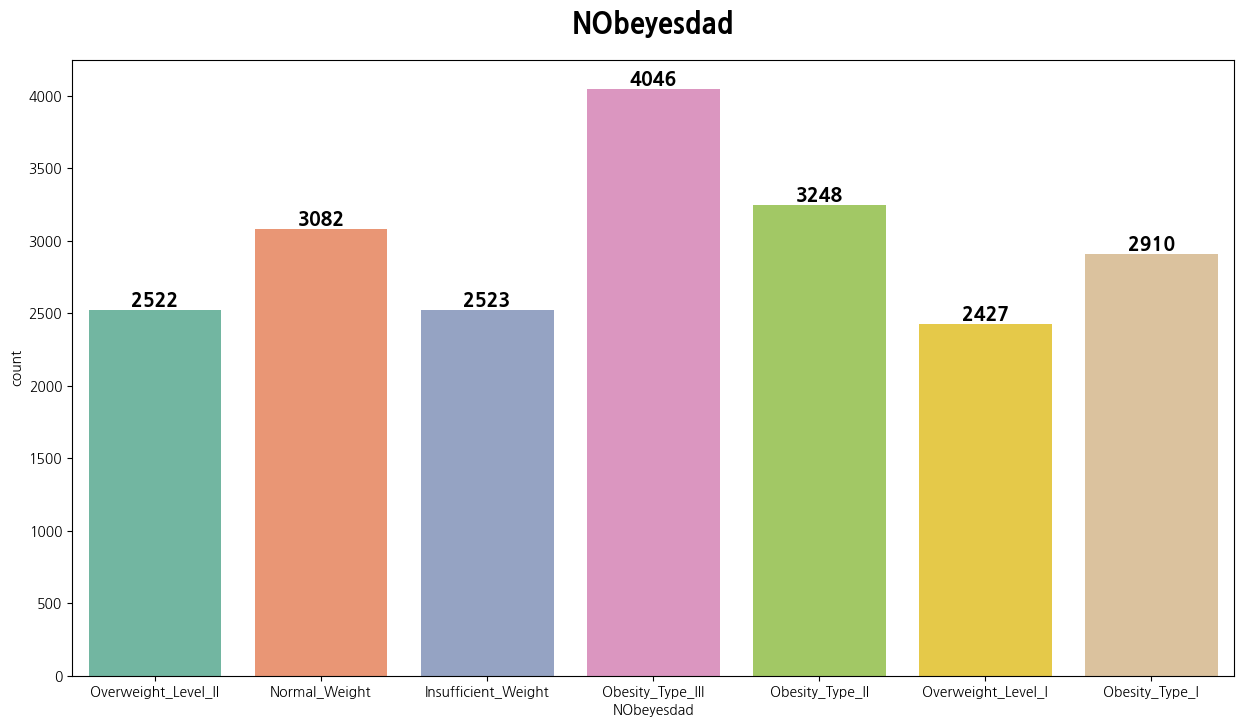

In [ ]:
plt.figure(figsize = (15, 8))

ax = sns.countplot(data = train, x = 'NObeyesdad', palette = 'Set2')
for i in ax.containers:
    ax.bar_label(i, fontweight = 'black', size = 14)
plt.title("NObeyesdad",fontweight="black",size=20,pad=20)

- Obesity_Type_III => is the most appear in data
- NO imbalance data

In [ ]:
train['Gender'].value_counts()

,count
Gender,
Female,10422
Male,10336


- Male & Female has similar number

In [ ]:
train['Age'].describe()

,Age
count,20758.000000
mean,23.841804
std,5.688072
min,14.000000
25%,20.000000
50%,22.815416
75%,26.000000
max,61.000000


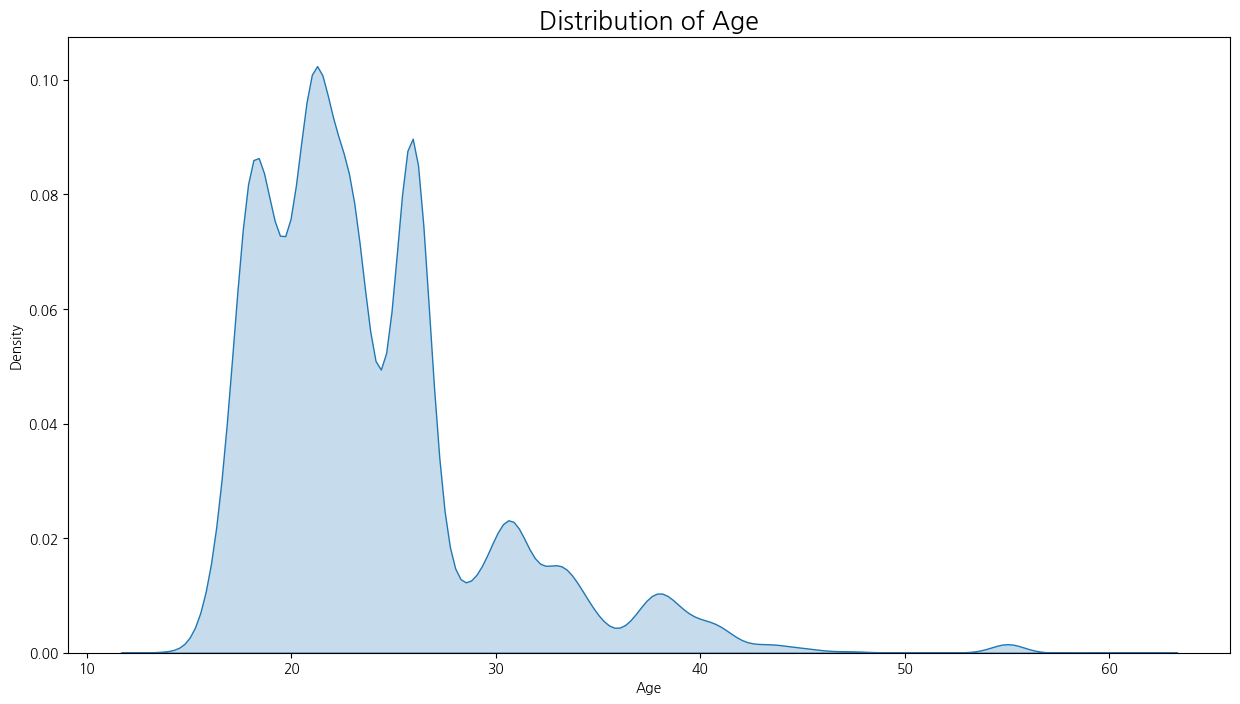

In [ ]:
plt.figure(figsize = (15, 8))
sns.kdeplot(data = train, x = 'Age', fill = True)
plt.title('Distribution of Age', size = 18)
plt.show()

- 분포 다양함 -> 나중에 scaler 사용 고려할 것

In [ ]:
train['Height'].describe()

,Height
count,20758.000000
mean,1.700245
std,0.087312
min,1.450000
25%,1.631856
50%,1.700000
75%,1.762887
max,1.975663


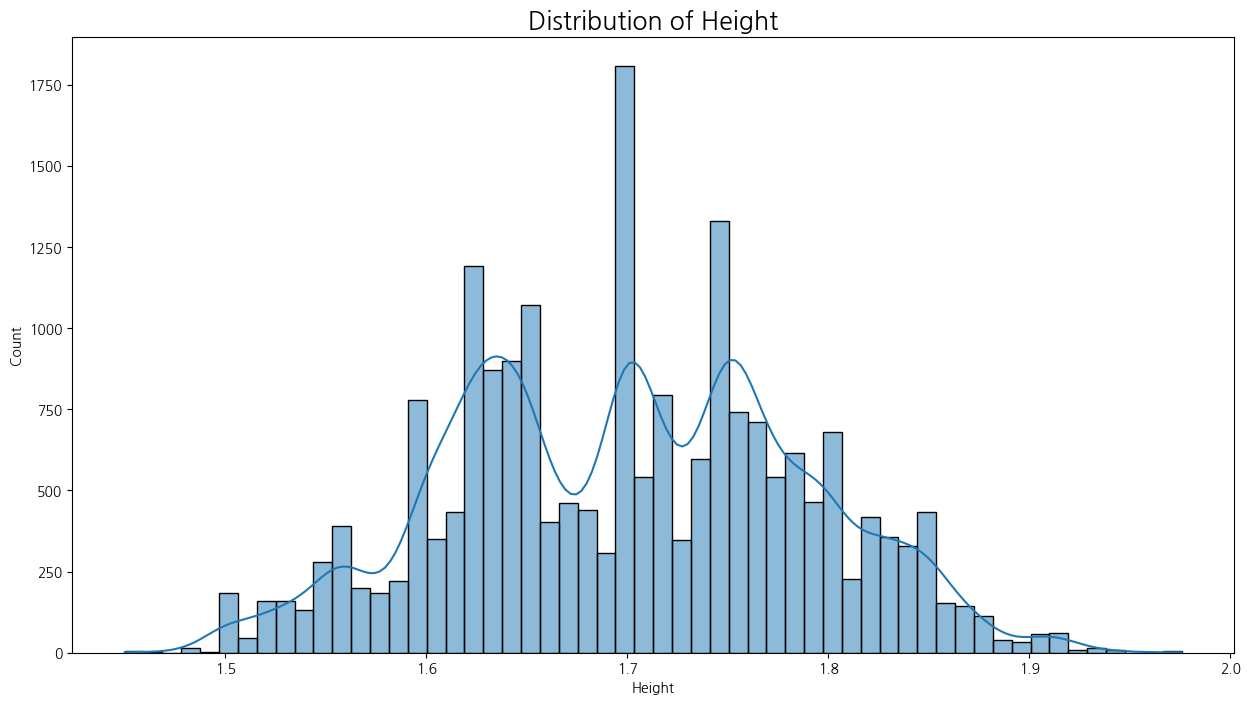

In [ ]:
plt.figure(figsize = (15, 8))
sns.histplot(data = train, x = 'Height', kde = True)
plt.title('Distribution of Height', size = 18)
plt.show()

- 정규분포를 따르는듯함
- 1.7이 가장 많음

In [ ]:
train['Weight'].describe()

,Weight
count,20758.000000
mean,87.887768
std,26.379443
min,39.000000
25%,66.000000
50%,84.064875
75%,111.600553
max,165.057269


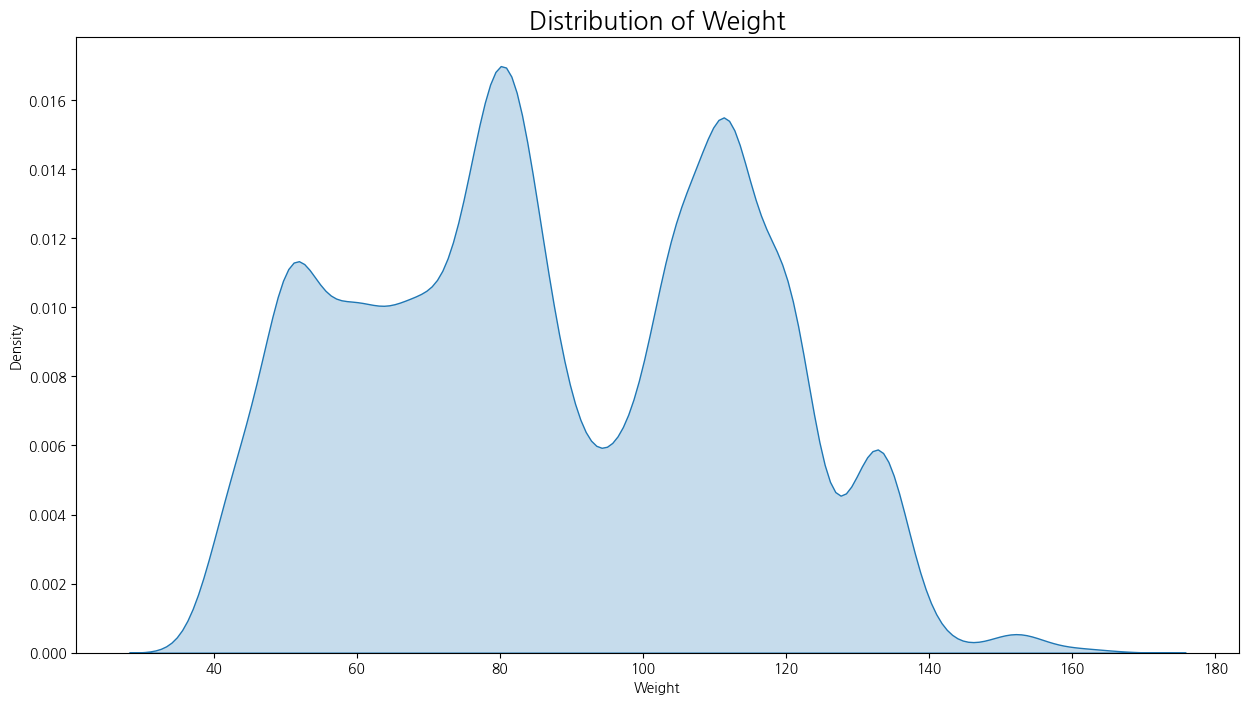

In [ ]:
plt.figure(figsize = (15, 8))
sns.kdeplot(data = train, x = 'Weight', fill = True)
plt.title('Distribution of Weight', size = 18)
plt.show()

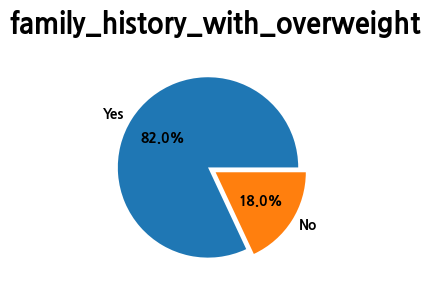

In [ ]:
plt.subplot(1,2,2)
plt.pie(train['family_history_with_overweight'].value_counts(), autopct = '%1.1f%%', explode = [0.1, 0], labels = ['Yes', 'No'], colors = sns.set_palette('Set2'),textprops={"fontweight":"black"})
plt.title("family_history_with_overweight",fontweight="black",size=20,pad=20)
plt.show()

<ipython-input-25-1536407650dd>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data = train, x = 'FAVC', palette = 'Set2')


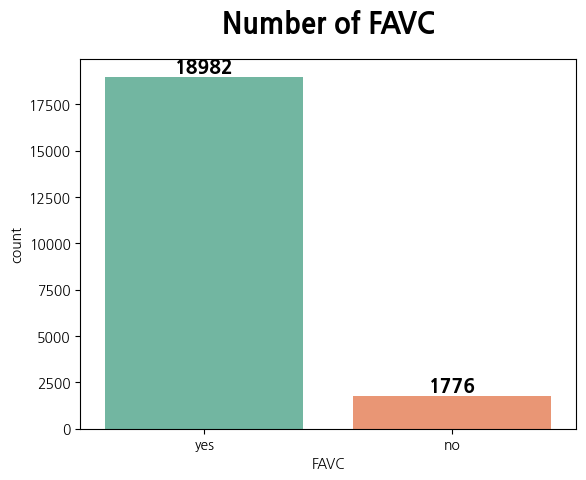

In [ ]:
ax = sns.countplot(data = train, x = 'FAVC', palette = 'Set2')
for i in ax.containers:
    ax.bar_label(i, fontweight = 'black', size = 14)
plt.title("Number of FAVC",fontweight="black",size=20,pad=20)
plt.show()

- large number of people consume high-calorie foods frequently

<ipython-input-26-56e41398b3d5>:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(data = train, x = 'FCVC', fill = True, palette = 'Set2')


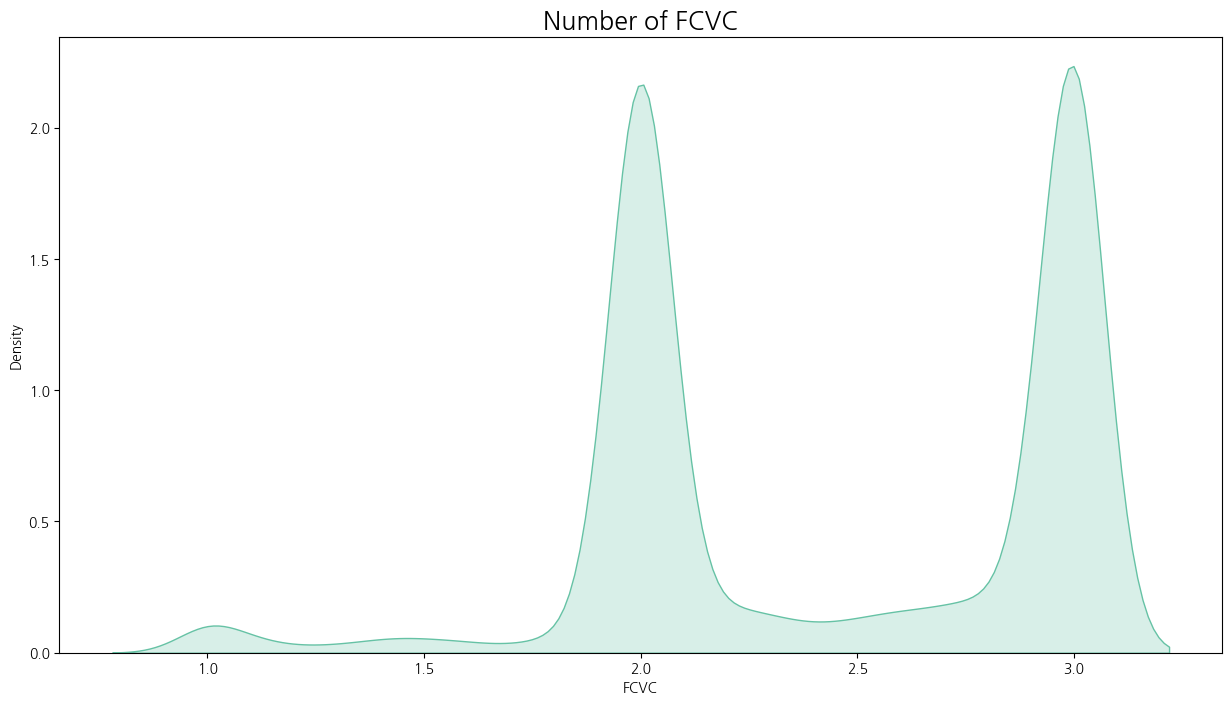

In [ ]:
plt.figure(figsize = (15, 8))
sns.kdeplot(data = train, x = 'FCVC', fill = True, palette = 'Set2')
plt.title('Number of FCVC', size = 18)
plt.show()

Most people consume vegetables at a moderate to high rate.
- 1 => consure (Rare)
- 2 => consume (Moderate)
- 3 => consume (High)

<ipython-input-27-46123bc0cf42>:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(data = train, x = 'NCP', fill = True, palette = 'Set2')


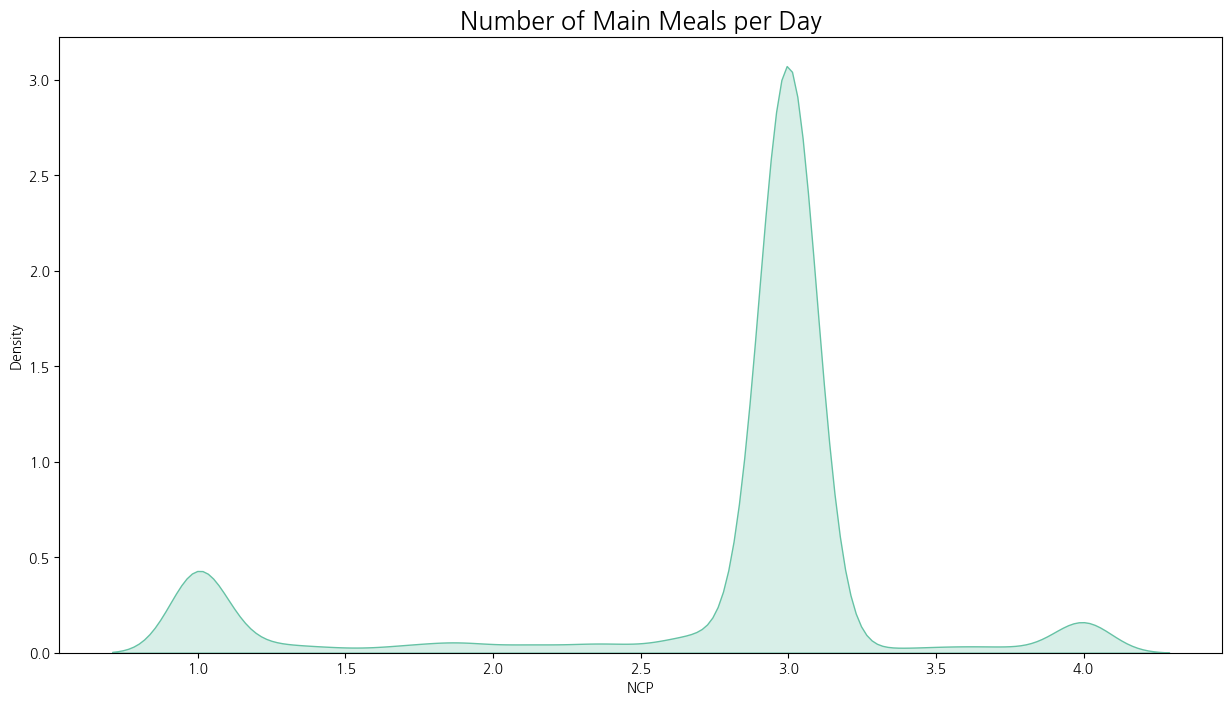

In [ ]:
plt.figure(figsize = (15, 8))
sns.kdeplot(data = train, x = 'NCP', fill = True, palette = 'Set2')
plt.title('Number of Main Meals per Day', size = 18)
plt.show()

- most people eat 3 times a day

<ipython-input-28-a2bbaef648a2>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data = train, x = 'CAEC', palette = 'Set2')


Text(0.5, 1.0, 'Consumption of Food Between Meals')

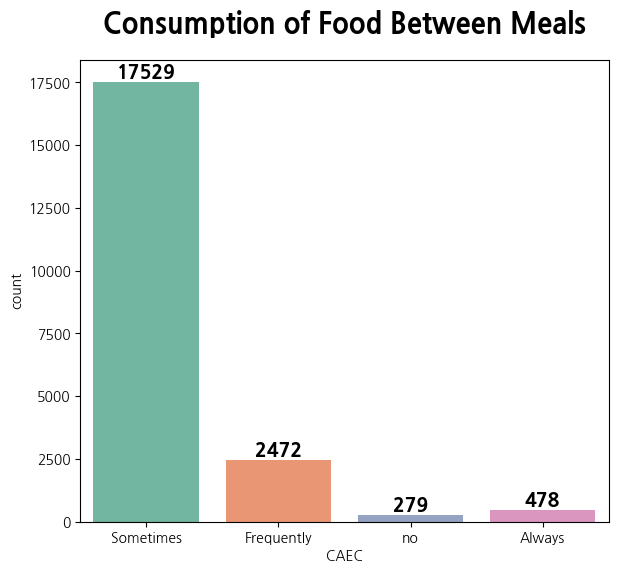

In [ ]:
plt.figure(figsize = (15, 6))

plt.subplot(1,2,1)
ax = sns.countplot(data = train, x = 'CAEC', palette = 'Set2')
for i in ax.containers:
    ax.bar_label(i, fontweight = 'black', size = 14)
plt.title("Consumption of Food Between Meals",fontweight="black",size=20,pad=20)

<ipython-input-29-7046f0756c77>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data = train, x = 'SMOKE', palette = 'Set2')


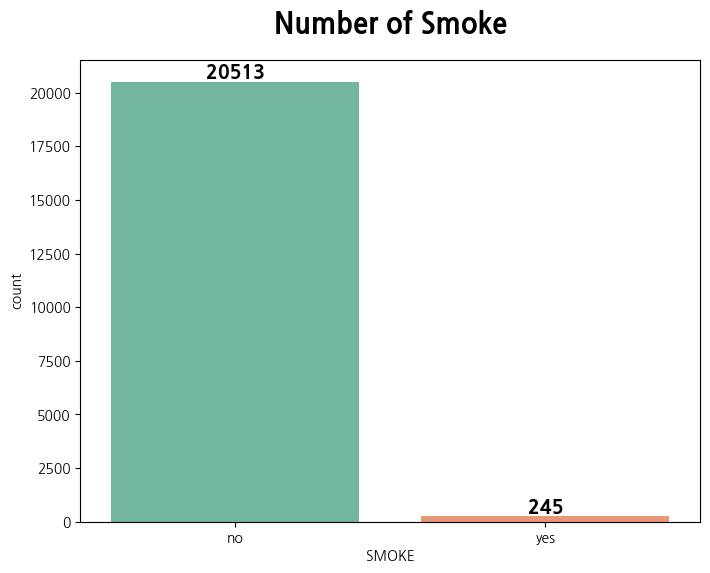

In [ ]:
plt.figure(figsize = (8, 6))
ax = sns.countplot(data = train, x = 'SMOKE', palette = 'Set2')
for i in ax.containers:
    ax.bar_label(i, fontweight = 'black', size = 14)
plt.title("Number of Smoke",fontweight="black",size=20,pad=20)
plt.show()

<ipython-input-30-e5de41899267>:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(data = train, x = 'CH2O', fill = True, palette = 'Set2')


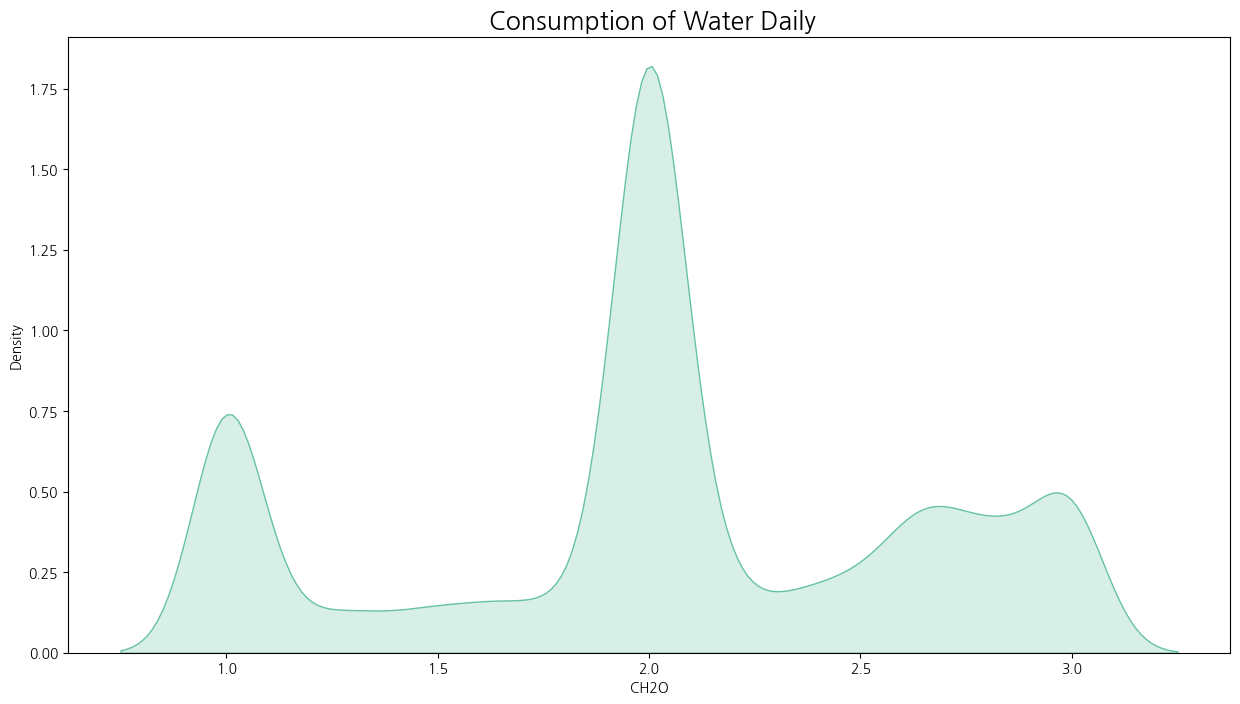

In [ ]:
plt.figure(figsize = (15, 8))
sns.kdeplot(data = train, x = 'CH2O', fill = True, palette = 'Set2')
plt.title(' Consumption of Water Daily', size = 18)
plt.show()

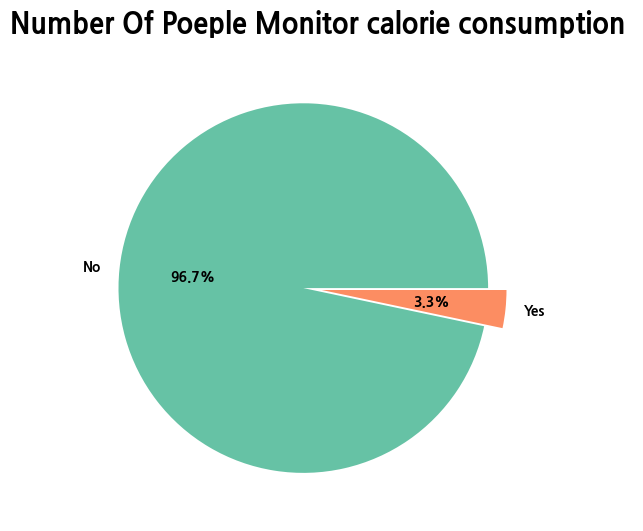

In [ ]:
plt.figure(figsize = (8, 6))
plt.pie(train['SCC'].value_counts(), autopct = '%1.1f%%', explode = [0.1, 0], labels = ['No', 'Yes'], colors = sns.set_palette('Set2'),textprops={"fontweight":"black"})
plt.title("Number Of Poeple Monitor calorie consumption ",fontweight="black",size=20,pad=20)
plt.show()

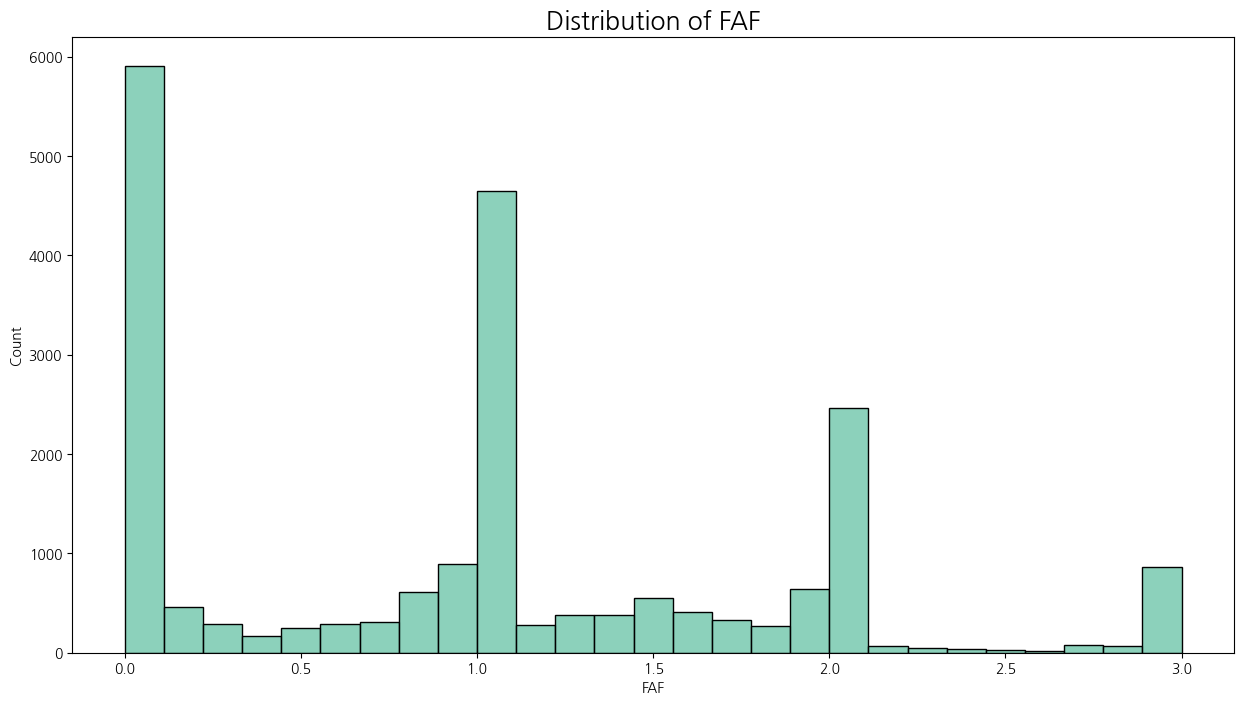

In [ ]:
plt.figure(figsize = (15, 8))
sns.histplot(data = train, x = 'FAF')
plt.title('Distribution of FAF', size = 18)
plt.show()

- 대부분 사람들은 physical activity 낮음

<ipython-input-33-c9a190711749>:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(data = train, x = 'TUE', fill = True, palette = 'Set2')


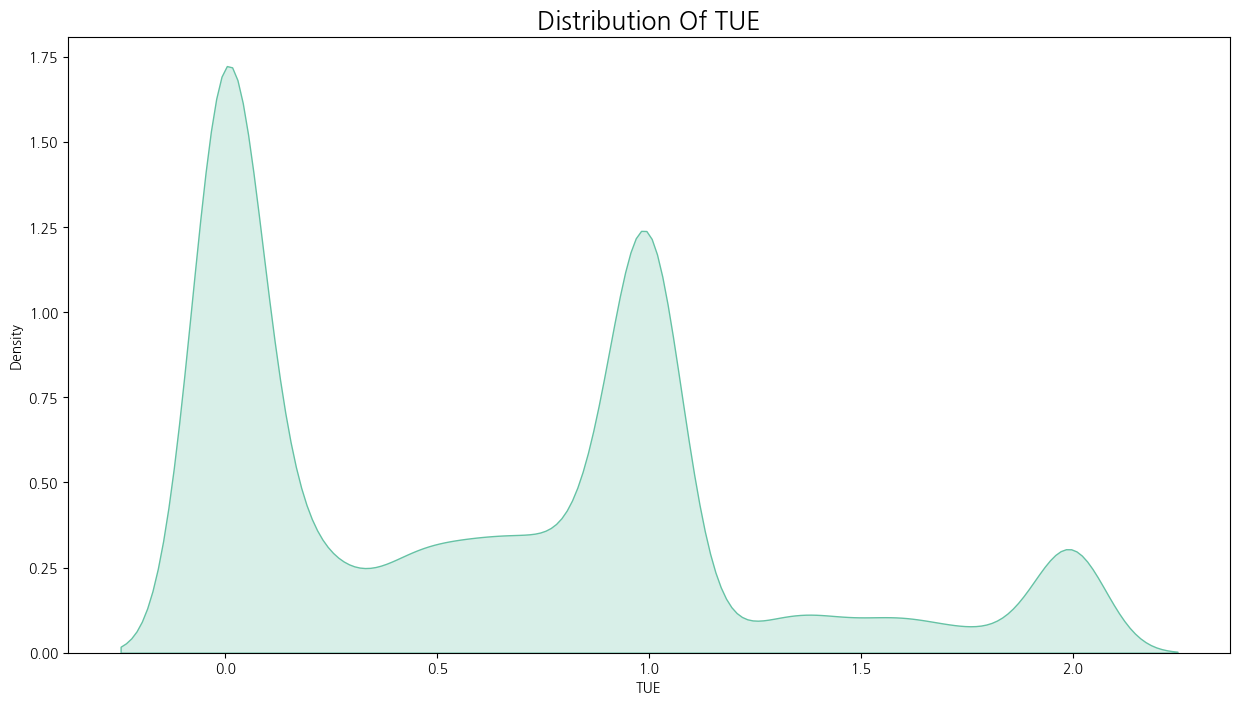

In [ ]:
plt.figure(figsize = (15, 8))
sns.kdeplot(data = train, x = 'TUE', fill = True, palette = 'Set2')
plt.title('Distribution Of TUE', size = 18)
plt.show()

<ipython-input-34-b91127bae4e2>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data = train, x = 'CALC', palette = 'Set2')
<ipython-input-34-b91127bae4e2>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data = train, x = 'MTRANS', palette = 'Set2')


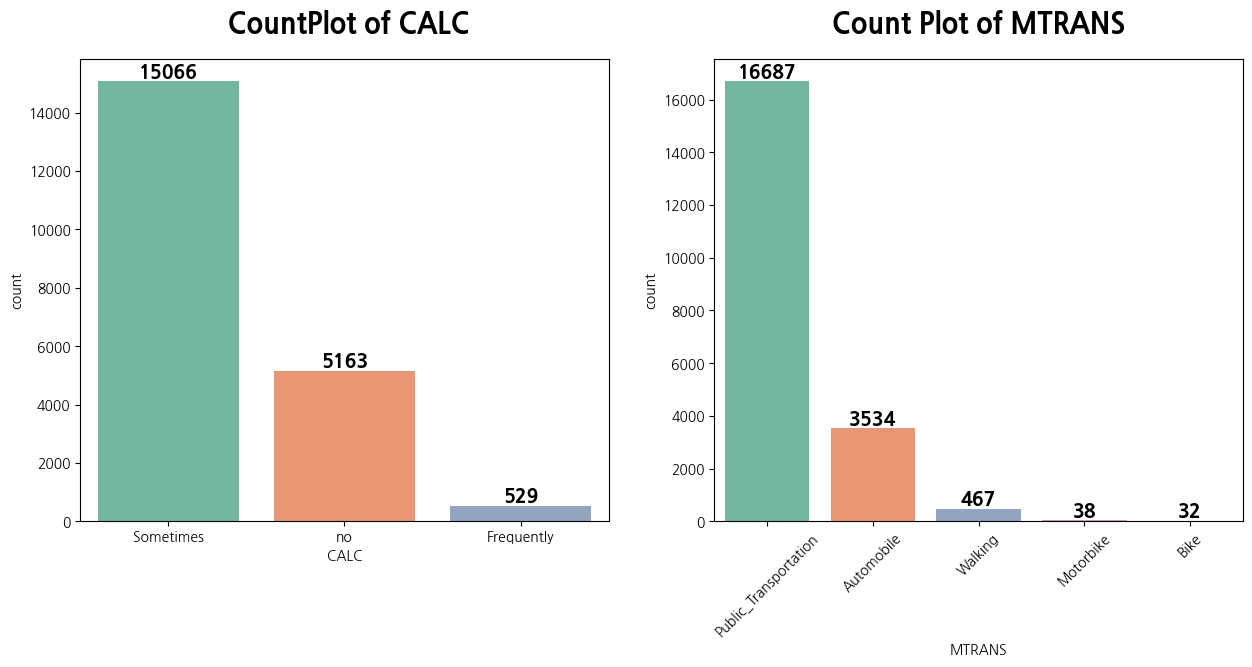

In [ ]:
plt.figure(figsize = (15, 6))

plt.subplot(1,2,1)
ax = sns.countplot(data = train, x = 'CALC', palette = 'Set2')
for i in ax.containers:
    ax.bar_label(i, fontweight = 'black', size = 14)
plt.title(" CountPlot of CALC",fontweight="black",size=20,pad=20)


plt.subplot(1,2,2)
ax = sns.countplot(data = train, x = 'MTRANS', palette = 'Set2')
for i in ax.containers:
    ax.bar_label(i, fontweight = 'black', size = 14)
plt.xticks(rotation = 45)
plt.title("Count Plot of MTRANS",fontweight="black",size=20,pad=20)
plt.show()

### 2. 상관계수 확인

In [ ]:
# 수치형 변수의 정규성 파악
from scipy.stats import shapiro

for col in numeric_cols:
  stat, p_value = shapiro(train[col])
  print(f"{col}: {stat}, {p_value}")

# p-value 모두 0.5 이상이므로 정규성 있음 -> 피어슨 상관계수 활용 가능

Age: 0.8729764391946926, 5.89596849522033e-83
Height: 0.9914173955502492, 4.967731637224898e-33
Weight: 0.9670943585110188, 5.1635528470867324e-55
FCVC: 0.7903467399124456, 8.167552246296466e-95
NCP: 0.6120934341841802, 1.7567975556556727e-110
CH2O: 0.9083630083709846, 1.1573092978537651e-75
FAF: 0.89688083388863, 2.9275785262522845e-78
TUE: 0.8580457985956733, 1.6228514807842886e-85


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 20758.
  res = hypotest_fun_out(*samples, **kwds)


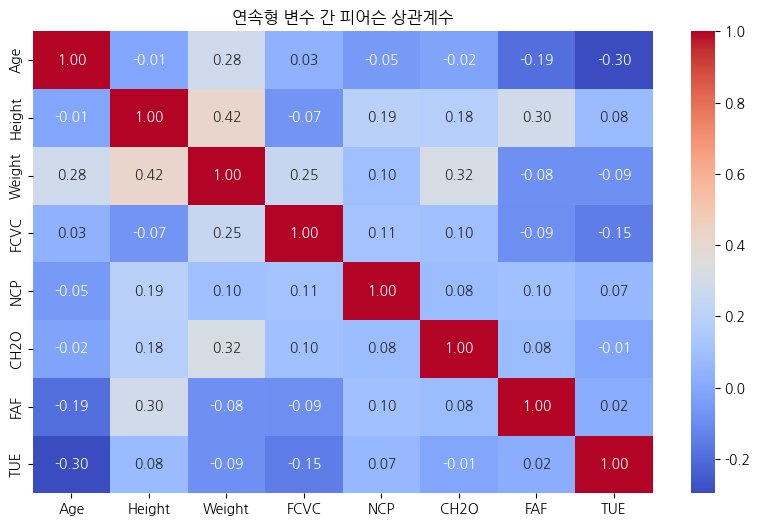

In [ ]:
numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
correlation_matrix = train[numeric_cols].corr(method='pearson')


plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("연속형 변수 간 피어슨 상관계수")
plt.show()

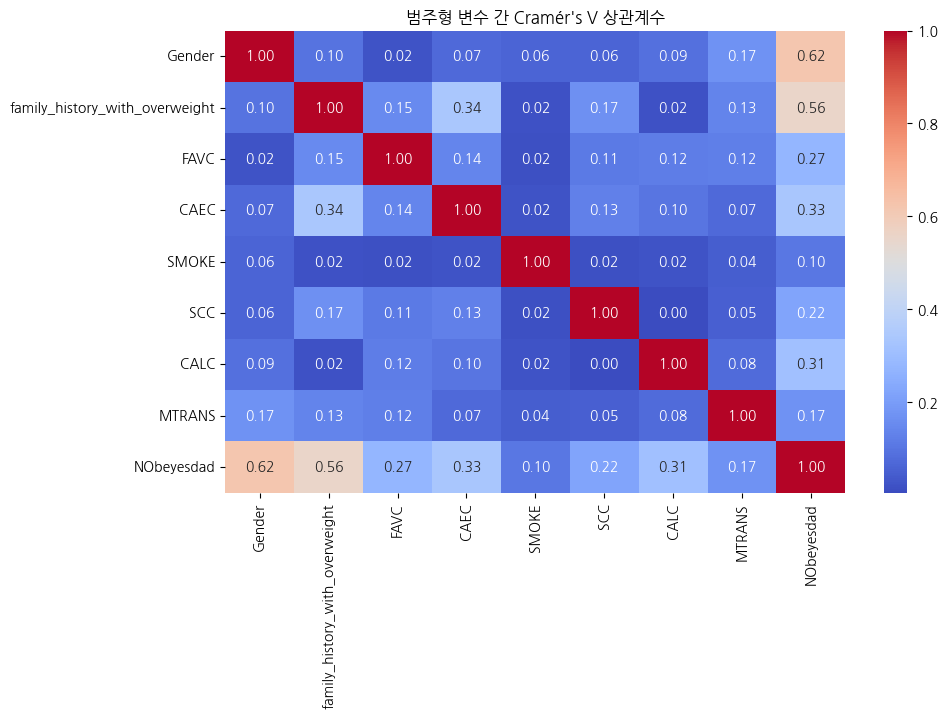

In [ ]:
# 범주형 변수 상관관계 파악
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

categorical_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']
cramers_v_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 != col2:
            cramers_v_matrix.loc[col1, col2] = cramers_v(train[col1], train[col2])
        else:
            cramers_v_matrix.loc[col1, col2] = 1  # 자기 자신과의 상관계수는 1

# Cramér's V 시각화
plt.figure(figsize=(10, 6))
sns.heatmap(cramers_v_matrix.astype(float), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("범주형 변수 간 Cramér's V 상관계수")
plt.show()

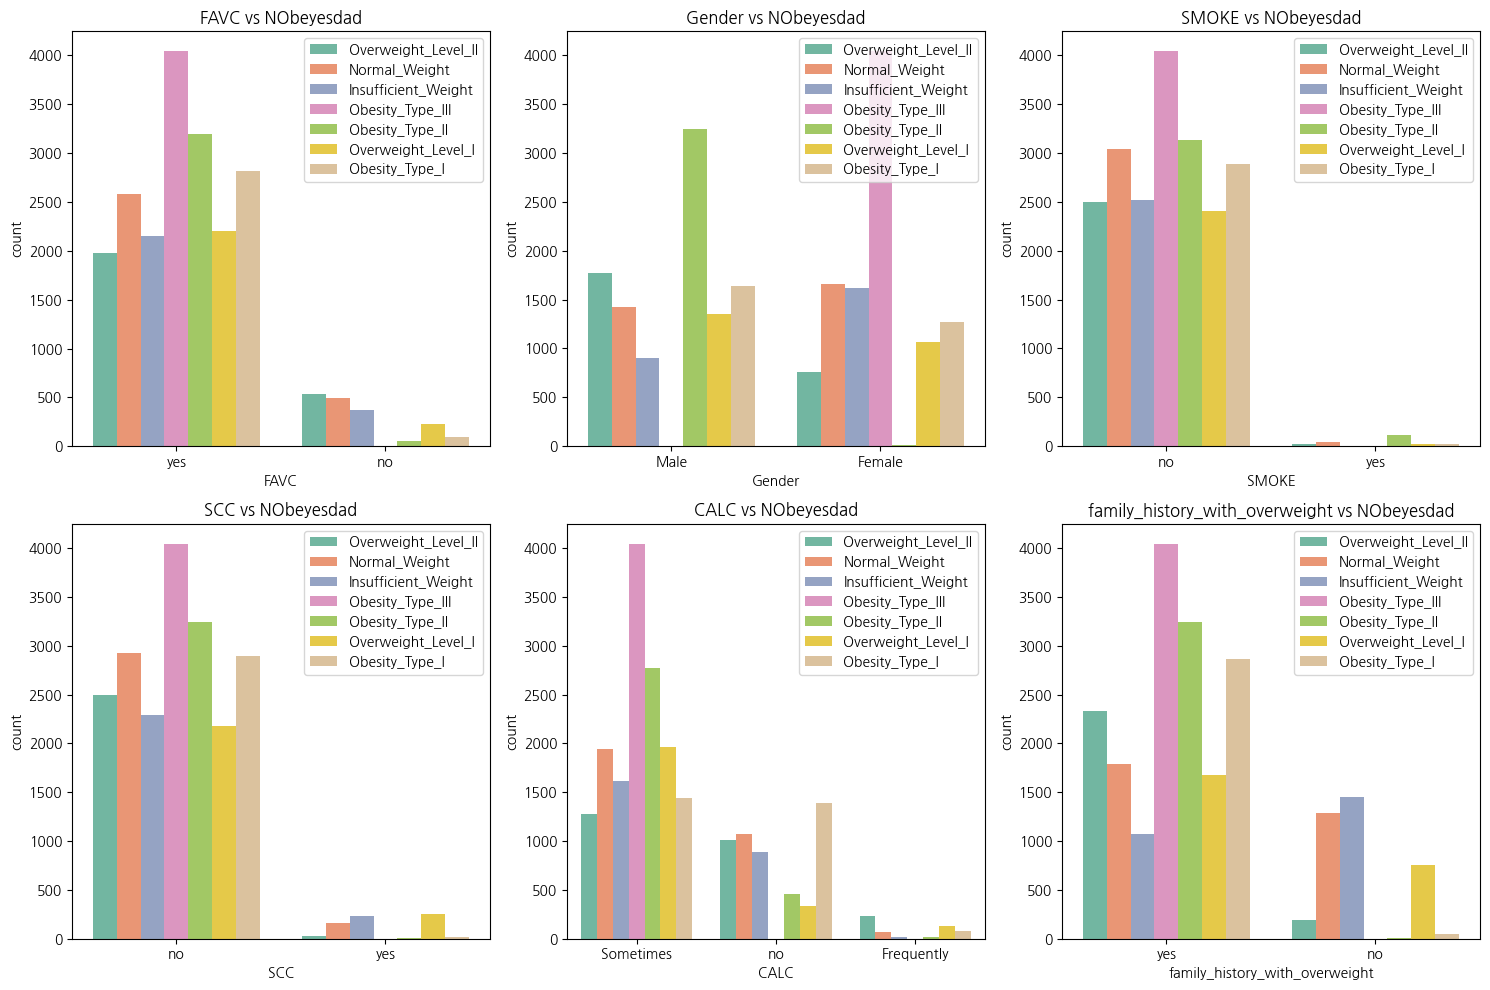

In [ ]:
plt.figure(figsize = (15, 10))
for ind, val in enumerate(['FAVC', 'Gender', 'SMOKE','SCC', 'CALC', 'family_history_with_overweight']):
    plt.subplot(2,3, ind + 1)
    sns.countplot(data = train, x = val, hue = 'NObeyesdad', palette = 'Set2')
    plt.legend(fontsize=10)
    plt.title(f'{val} vs NObeyesdad')

plt.tight_layout()
plt.show()

In [ ]:
import scipy.stats as stats

for col in numeric_cols:
    anova_groups = [train[train["NObeyesdad"] == category][col] for category in train["NObeyesdad"].unique()]
    f_stat, p_value = stats.f_oneway(*anova_groups)

    print(f"ANOVA for {col}:")
    print(f"F-statistic: {f_stat}, p-value: {p_value}")
    if p_value < 0.05:
        print(f"{col}와 NObeyesdad 사이에 유의미한 차이가 있음.\n")
    else:
        print(f"{col}와 NObeyesdad 사이에 유의미한 차이가 없음.\n")


ANOVA for Age:
F-statistic: 962.9364958985186, p-value: 0.0
Age와 NObeyesdad 사이에 유의미한 차이가 있음.

ANOVA for Height:
F-statistic: 759.5796632267953, p-value: 0.0
Height와 NObeyesdad 사이에 유의미한 차이가 있음.

ANOVA for Weight:
F-statistic: 22867.94586637475, p-value: 0.0
Weight와 NObeyesdad 사이에 유의미한 차이가 있음.

ANOVA for FCVC:
F-statistic: 1551.9182782871674, p-value: 0.0
FCVC와 NObeyesdad 사이에 유의미한 차이가 있음.

ANOVA for NCP:
F-statistic: 300.2597054229269, p-value: 0.0
NCP와 NObeyesdad 사이에 유의미한 차이가 있음.

ANOVA for CH2O:
F-statistic: 385.8187268148889, p-value: 0.0
CH2O와 NObeyesdad 사이에 유의미한 차이가 있음.

ANOVA for FAF:
F-statistic: 282.71468070355667, p-value: 0.0
FAF와 NObeyesdad 사이에 유의미한 차이가 있음.

ANOVA for TUE:
F-statistic: 147.1885754792915, p-value: 1.4249546777412344e-183
TUE와 NObeyesdad 사이에 유의미한 차이가 있음.



- ANOVA: NObeyesdad 와의 관계에서 수치형 변수 모두 높은 상관관계를 가지고 있음
- FAVC(frequent high-calorie food consumption): yes -> obesity
- Smoke: No -> obesity
  그러나 데이터 상에서 No smoke이 더 많았기 때문에 당연한 결과
- family history with obesity: yes -> obesity

주목해야할 컬럼은 Family history with obesity, Gender

### 3. Feature Engineering

BMI 지수 생성


In [ ]:
train["BMI"] = train["Weight"] / (train["Height"] ** 2)

In [ ]:
test["BMI"] = test["Weight"] / (test["Height"] ** 2)

<ipython-input-8-0b908ac9281f>:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(data = train, x = 'BMI', fill = True, palette = 'Set2')


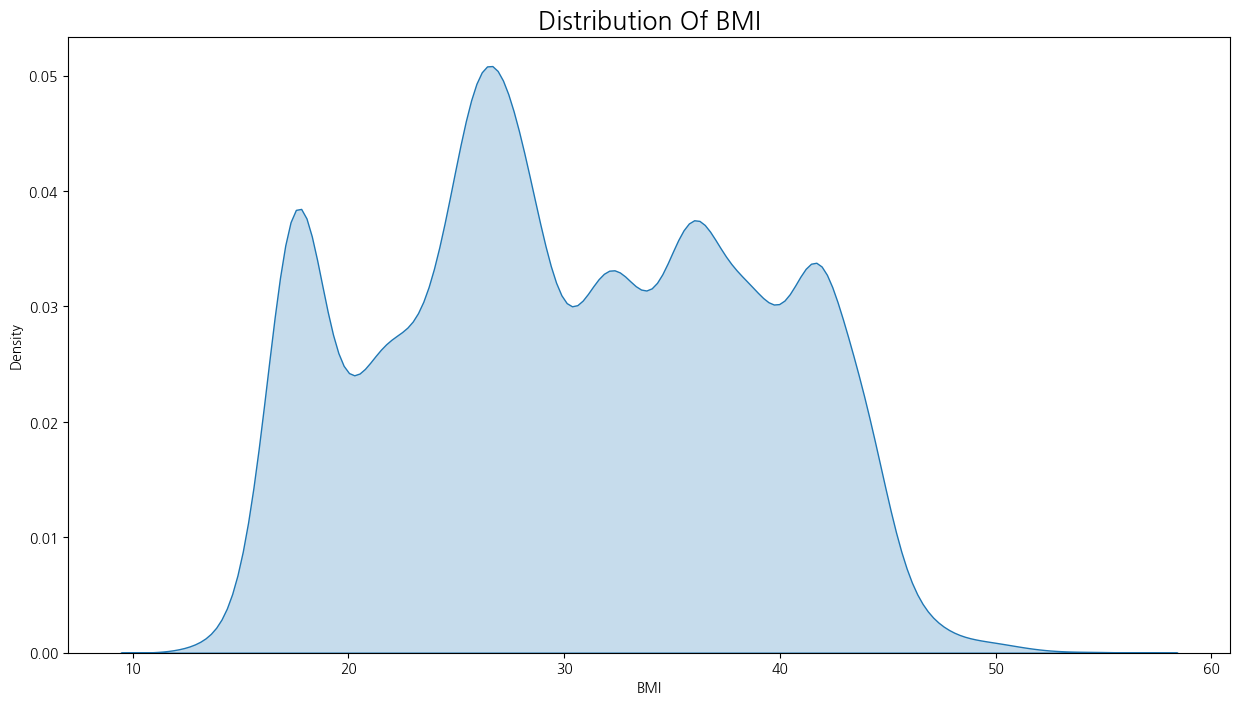

In [ ]:
plt.figure(figsize = (15, 8))
sns.kdeplot(data = train, x = 'BMI', fill = True, palette = 'Set2')
plt.title('Distribution Of BMI', size = 18)
plt.show()

식습관 점수 계산
- 식습관 관련 변수(FAVC, FCVC, NCP, CAEC, CH2O, CALC) 활용하여 파생 변수 생성
- ANOVA, 피어슨, 스피어만 상관계수로 target 변수와의 상관계수 파악 결과 상관관계를 가짐을 파악
  - 0.263 (피어슨)과 0.255 (스피어만)는 "약한 양의 상관관계"에 해당
  - Healthy_Eating_Score가 높을수록 NObeyesdad도 증가하는 경향이 있지만, 강한 관계는 아님
  - p-value = 0.0 이므로 통계적으로 유의미

→ 따라서 랜덤포레스트 같은 비선형 모델을 활용하는 것이 좋을수도?

In [ ]:
# 건강한 식습관 (높을수록 건강한 식습관)
train["Healthy_Eating_Score"] = train["FCVC"] + train["CH2O"] - (train["FAVC"].map({"yes": 1, "no": 0}) + train["CAEC"].map({"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}))

In [ ]:
anova_groups = [train[train["NObeyesdad"] == category]["Healthy_Eating_Score"] for category in train["NObeyesdad"].unique()]
f_stat, p_value = stats.f_oneway(*anova_groups)
print(f"f_stat: {f_stat}, p_value: {p_value}")

f_stat: 1067.343321887604, p_value: 0.0


In [ ]:
from scipy.stats import pearsonr, spearmanr

# NObeyesdad를 숫자로 변환
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
train["NObeyesdad_encoded"] = encoder.fit_transform(train[["NObeyesdad"]])

# 피어슨 상관계수
pearson_corr, p_value_pearson = pearsonr(train["Healthy_Eating_Score"], train["NObeyesdad_encoded"])
print(f"Pearson Correlation: {pearson_corr}, p-value: {p_value_pearson}")

# 스피어만 상관계수 (비선형 관계 고려)
spearman_corr, p_value_spearman = spearmanr(train["Healthy_Eating_Score"], train["NObeyesdad_encoded"])
print(f"Spearman Correlation: {spearman_corr}, p-value: {p_value_spearman}")


Pearson Correlation: 0.26343093694805125, p-value: 0.0
Spearman Correlation: 0.25473254526584516, p-value: 9.04699413357783e-305


In [ ]:
test["Healthy_Eating_Score"] = test["FCVC"] + test["CH2O"] - (test["FAVC"].map({"yes": 1, "no": 0}) + test["CAEC"].map({"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}))

실제 활동 관련 지표 계산
- 좌식 생활 점수: FAF가 낮고 TUE가 높을수록 좌식 생활 지수 증가
- Pearson, Spearson 상관계수 확인 결과 target 변수와의 상관성 낮음

→ 기각

In [ ]:
# 좌식 생활 점수 (FAF가 낮고 TUE가 높을수록 좌식 생활 지수 증가)
train["Sedentary_Score"] = train["TUE"] - train["FAF"]

In [ ]:
pearson_corr, p_value_pearson = pearsonr(train["Sedentary_Score"], train["NObeyesdad_encoded"])
print(f"Pearson Correlation: {pearson_corr}, p-value: {p_value_pearson}")

# 스피어만 상관계수 (비선형 관계 고려)
spearman_corr, p_value_spearman = spearmanr(train["Sedentary_Score"], train["NObeyesdad_encoded"])
print(f"Spearman Correlation: {spearman_corr}, p-value: {p_value_spearman}")

Pearson Correlation: 0.03448313790557758, p-value: 6.716597871692912e-07
Spearman Correlation: 0.061186746360815905, p-value: 1.1113446347962823e-18


In [ ]:
train.drop(columns = ['Sedentary_Score'], inplace = True)

변수 인코딩

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# NObeyesdad를 숫자로 변환 (저체중 → 비만 순서대로)
encoder = OrdinalEncoder(categories=[['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II',
                                      'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']])
train["NObeyesdad_encoded"] = encoder.fit_transform(train[["NObeyesdad"]])

### 4. Clustering

1) Age Clustering

In [ ]:
from sklearn.cluster import KMeans
age_data = train[["Age"]]

# k = 3
kmeans_age = KMeans(n_clusters=3, random_state=42)
train["Age_Cluster"] = kmeans_age.fit_predict(age_data)

print(train[["Age", "Age_Cluster"]].head())

plt.figure(figsize=(10, 6))
sns.scatterplot(data=train, x="Age_Cluster", y="Age", palette="viridis", alpha=0.7)
plt.title("K-Means Clustering (Age)")
plt.show()

NameError: name 'train' is not defined

In [ ]:
# 최적의 K 찾기; k = 3
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(age_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

2) BMI

In [ ]:
bmi_data = train[["BMI"]]

# k = 3
kmeans_bmi = KMeans(n_clusters=3, random_state=42)
train["BMI_Cluster"] = kmeans_bmi.fit_predict(bmi_data)

print(train[["BMI", "BMI_Cluster"]].head())


In [ ]:
# 최적의 K 찾기; k = 3
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(bmi_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

3) test 에도 똑같이 적용

In [ ]:
age_data = test[["Age"]]
bmi_data = test[["BMI"]]

kmeans_age = KMeans(n_clusters=3, random_state=42)
test["Age_Cluster"] = kmeans_age.fit_predict(age_data)
test["BMI_Cluster"] = kmeans_bmi.fit_predict(bmi_data)

print(test[["Age", "Age_Cluster", "BMI", "BMI_Cluster"]].head())

### Polynomial Features

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = ["Age", "BMI"]

# 🔹 Polynomial 변환 (2차)
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_transformed = poly.fit_transform(train[poly_features])

poly_df = pd.DataFrame(poly_transformed, columns=poly.get_feature_names_out(poly_features))

train["Age"] = poly_df["Age"]
train["BMI"] = poly_df["BMI"]

train = pd.concat([train, poly_df.drop(columns=["Age", "BMI"])], axis=1)

train.columns


Index(['id', 'Gender', 'Age', 'Height', 'Weight',
       'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC',
       'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad',
       'BMI', 'Healthy_Eating_Score', 'NObeyesdad_encoded', 'Age_Cluster',
       'BMI_Cluster', 'Age^2', 'Age BMI', 'BMI^2'],
      dtype='object')

### 5. Data Transformation

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
categorical_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

In [ ]:
encoder = LabelEncoder()

for i in train[categorical_cols]:
    train[i] =  encoder.fit_transform(train[i])

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  int64  
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  int64  
 6   FAVC                            20758 non-null  int64  
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float64
 9   CAEC                            20758 non-null  int64  
 10  SMOKE                           20758 non-null  int64  
 11  CH2O                            20758 non-null  float64
 12  SCC                             

In [ ]:
test_cols = test.select_dtypes(include = 'O').columns

In [ ]:
for i in test[test_cols]:
   test[i] =  encoder.fit_transform(test[i])

In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13840 entries, 0 to 13839
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              13840 non-null  int64  
 1   Gender                          13840 non-null  int64  
 2   Age                             13840 non-null  float64
 3   Height                          13840 non-null  float64
 4   Weight                          13840 non-null  float64
 5   family_history_with_overweight  13840 non-null  int64  
 6   FAVC                            13840 non-null  int64  
 7   FCVC                            13840 non-null  float64
 8   NCP                             13840 non-null  float64
 9   CAEC                            13840 non-null  int64  
 10  SMOKE                           13840 non-null  int64  
 11  CH2O                            13840 non-null  float64
 12  SCC                             

### 6. Data Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
scale_features = ["Height", "Weight", "BMI", "Age"]
scaler = StandardScaler()
train[scale_features] = scaler.fit_transform(train[scale_features])

In [ ]:
scale_features = ["Height", "Weight", "BMI", "Age"]
scaler = StandardScaler()
test[scale_features] = scaler.fit_transform(test[scale_features])

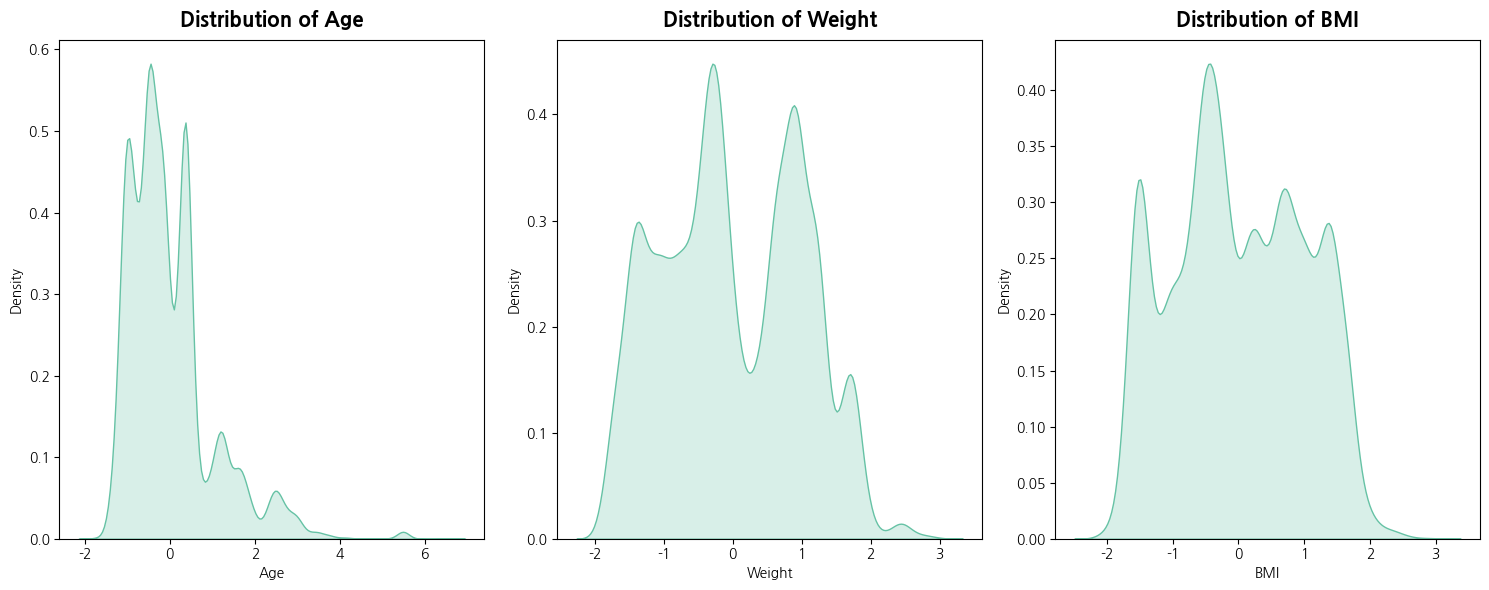

In [ ]:
plt.figure(figsize = (15, 6))

plt.subplot(1, 3, 1)
sns.kdeplot(data=train, x="Age", fill=True)
plt.title("Distribution of Age", fontweight="black", size=15, pad=10)

plt.subplot(1, 3, 2)
sns.kdeplot(data=train, x="Weight", fill=True)
plt.title("Distribution of Weight", fontweight="black", size=15, pad=10)

plt.subplot(1, 3, 3)
sns.kdeplot(data=train, x="BMI", fill=True)
plt.title("Distribution of BMI", fontweight="black", size=15, pad=10)

plt.tight_layout()
plt.show()

### 7. Training Model

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  int64  
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  int64  
 6   FAVC                            20758 non-null  int64  
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float64
 9   CAEC                            20758 non-null  int64  
 10  SMOKE                           20758 non-null  int64  
 11  CH2O                            20758 non-null  float64
 12  SCC                             

In [ ]:
train.drop(columns = ['NObeyesdad', 'id'], inplace = True)

In [ ]:
# !pip uninstall -y pycaret cuml
!pip install -U pycaret

#### Pycaret

In [ ]:
from pycaret.classification import *

clf = setup(data=train,
            target="NObeyesdad_encoded",
            train_size=0.8,
            session_id=42,
            use_gpu = False,
            verbose = False
)

best_model = compare_models(sort="Accuracy")
final_model = finalize_model(best_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
catboost,CatBoost Classifier,0.9056,0.9904,0.9056,0.9056,0.9054,0.8892,0.8893,42.5810
lightgbm,Light Gradient Boosting Machine,0.9034,0.9901,0.9034,0.9036,0.9032,0.8867,0.8868,8.5160
xgboost,Extreme Gradient Boosting,0.9030,0.9901,0.9030,0.9031,0.9027,0.8862,0.8863,2.6090
gbc,Gradient Boosting Classifier,0.8999,0.0000,0.8999,0.8998,0.8995,0.8825,0.8826,30.8140
rf,Random Forest Classifier,0.8961,0.9873,0.8961,0.8963,0.8959,0.8782,0.8783,3.0190
et,Extra Trees Classifier,0.8943,0.9867,0.8943,0.8945,0.8940,0.8760,0.8761,1.6740
lda,Linear Discriminant Analysis,0.8405,0.0000,0.8405,0.8460,0.8402,0.8131,0.8140,0.0690
dt,Decision Tree Classifier,0.8362,0.9057,0.8362,0.8363,0.8361,0.8079,0.8079,0.2300
knn,K Neighbors Classifier,0.8313,0.9506,0.8313,0.8320,0.8312,0.8022,0.8023,0.4670
nb,Naive Bayes,0.8225,0.9720,0.8225,0.8294,0.8201,0.7922,0.7939,0.1200


Processing:   0%|          | 0/69 [00:00<?, ?it/s]

In [ ]:
tuned_lgbm = tune_model(best_model, optimize="Accuracy", search_library="scikit-learn", search_algorithm="random")
final_lgbm = finalize_model(tuned_lgbm)
evaluate_model(final_lgbm)

In [ ]:
test_X = test.drop(columns = ['id'])
predictions = predict_model(final_lgbm, data=test_X)

#### LightGBM

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
X = train.drop(columns=["NObeyesdad_encoded"])
y = train["NObeyesdad_encoded"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
lgbm = lgb.LGBMClassifier(objective="multiclass", num_class=len(y.unique()), random_state=42)

lgbm.fit(X_train, y_train)
y_pred = lgbm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"LightGBM 모델 정확도: {accuracy:.4f}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003414 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2553
[LightGBM] [Info] Number of data points in the train set: 16606, number of used features: 18
[LightGBM] [Info] Start training from score -2.117117
[LightGBM] [Info] Start training from score -1.911230
[LightGBM] [Info] Start training from score -2.145531
[LightGBM] [Info] Start training from score -2.112625
[LightGBM] [Info] Start training from score -1.948141
[LightGBM] [Info] Start training from score -1.857720
[LightGBM] [Info] Start training from score -1.633574
LightGBM 모델 정확도: 0.9029


In [ ]:
test_X = test.drop(columns = ['id'])
y_pred = lgbm.predict(test_X)
print(y_pred)

[5. 2. 6. ... 0. 1. 5.]


- LightGBM 랜덤 서치로 하이퍼파라미터 튜닝

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "num_leaves": [20, 31, 40, 50],
    "max_depth": [-1, 5, 10, 15],
    "n_estimators": [50, 100, 200]
}

random_search = RandomizedSearchCV(lgb.LGBMClassifier(objective="multiclass", num_class=len(y.unique()), random_state=42),
                                   param_distributions=param_grid,
                                   n_iter=20,
                                   scoring="accuracy",
                                   cv=3,
                                   random_state=42,
                                   verbose=2,
                                   n_jobs=-1)

random_search.fit(X_train, y_train)
print("최적 하이퍼파라미터:", random_search.best_params_)

best_lgbm = random_search.best_estimator_
y_pred_best = best_lgbm.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"튜닝된 LightGBM 모델 정확도: {accuracy_best:.4f}")


Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002798 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2553
[LightGBM] [Info] Number of data points in the train set: 16606, number of used features: 18
[LightGBM] [Info] Start training from score -2.117117
[LightGBM] [Info] Start training from score -1.911230
[LightGBM] [Info] Start training from score -2.145531
[LightGBM] [Info] Start training from score -2.112625
[LightGBM] [Info] Start training from score -1.948141
[LightGBM] [Info] Start training from score -1.857720
[LightGBM] [Info] Start training from score -1.633574
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [ ]:
y_pred = best_lgbm.predict(test_X)
print(y_pred)

#### CatBoost

In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.1 MB/s eta 0:00:00


In [ ]:
import catboost as cb

cat_model = cb.CatBoostClassifier(iterations=100,
                                  depth=6,
                                  learning_rate=0.1,
                                  loss_function="MultiClass",
                                  random_state=42,
                                  verbose=0)

cat_features = [col for col in X_train.columns if X_train[col].dtype == "object"]
cat_model.fit(X_train, y_train, cat_features=cat_features)

y_pred_cat = cat_model.predict(X_test)

accuracy_cat = accuracy_score(y_test, y_pred_cat)
print(f"CatBoost 모델 정확도: {accuracy_cat:.4f}")


CatBoost 모델 정확도: 0.8923


Catboost 하이퍼 파라미터 튜닝

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "iterations": [100, 200, 300],
    "depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "l2_leaf_reg": [1, 3, 5, 7, 9]
}

random_search = RandomizedSearchCV(cb.CatBoostClassifier(loss_function="MultiClass", random_state=42),
                                   param_distributions=param_grid,
                                   n_iter=20,
                                   scoring="accuracy",
                                   cv=3,
                                   random_state=42,
                                   verbose=2,
                                   n_jobs=-1)


random_search.fit(X_train, y_train, cat_features=cat_features)
print("최적 하이퍼파라미터:", random_search.best_params_)

best_cat = random_search.best_estimator_
y_pred_best = best_cat.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"튜닝된 CatBoost 모델 정확도: {accuracy_best:.4f}")


Fitting 3 folds for each of 20 candidates, totalling 60 fits


KeyboardInterrupt: 

In [ ]:
y_pred = best_cat.predict(test_X)
print(y_pred)

In [ ]:
y_pred = y_pred.ravel()
y_pred

#### XGBoost

- BMI 지수가 있기 때문에 Height, Weight를 drop 결정

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score ,f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV

In [ ]:
def train_model(model):
    model.fit(X_train, y_train)
    print(f'Train Score => {model.score(X_train, y_train)}')
    print(f'Test Score => {model.score(X_test, y_test)}')
    y_pred = model.predict(X_test)
    print(classification_report(y_pred, y_test))

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators = 300, max_depth = 3, learning_rate = 0.1)
train_model(xgb)

In [ ]:
params = {'n_estimators': [100, 200, 300],
         'learning_rate': [0.1, 0.01, 0.001],
         'max_depth': [3, 6, 9]}

score = 'accuracy'

In [ ]:
model_xgb = GridSearchCV(xgb, params, scoring = score, n_jobs = -1)
model_xgb.fit(X_train, y_train)
print(model_xgb.best_params_)
print(model_xgb.best_score_)

In [ ]:
best_xgb = model_xgb.best_estimator_
y_pred = best_xgb.predict(test_X)
print(y_pred)

#### Ensemble
- soft voting 방식으로 진행

In [ ]:
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(objective="multi:softmax", num_class=len(y.unique()), random_state=42)
cat = CatBoostClassifier(loss_function="MultiClass", verbose=0, random_state=42)
lgbm = LGBMClassifier(objective="multiclass", num_class=len(y.unique()), random_state=42)


voting_clf = VotingClassifier(
    estimators=[('xgb', xgb), ('cat', cat), ('lgbm', lgbm)],
    voting='soft',
    n_jobs=-1
)


voting_clf.fit(X_train, y_train)
y_pred = voting_clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Voting Ensemble Model Accuracy: {accuracy:.4f}")


In [ ]:
pred_X = voting_clf.predict(test_X)
print(pred_X)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import StackingClassifier

# Stacking 앙상블 (최종 메타 모델: 랜덤포레스트)
stacking_clf = StackingClassifier(
    estimators=[('xgb', xgb), ('cat', cat), ('lgbm', lgbm)],
    final_estimator=RandomForestClassifier(n_estimators=100, random_state=42),
    n_jobs=-1
)

stacking_clf.fit(X_train, y_train)
y_pred_stack = stacking_clf.predict(X_test)
accuracy_stack = accuracy_score(y_test, y_pred_stack)

print(f"Stacking Ensemble (RF) Model Accuracy: {accuracy_stack:.4f}")


In [ ]:
pred_X = stacking_clf.predict(test_X)
print(pred_X)

### 8. Feature Importance

In [ ]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier()
lgbm.fit(X_train, y_train)

importance_df = pd.DataFrame({"Feature": X_train.columns, "Importance": lgbm.feature_importances_})
importance_df = importance_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance (LightGBM)")
plt.gca().invert_yaxis()
plt.show()


In [ ]:
print(train["FAVC"].value_counts(normalize=True))
print(train["SMOKE"].value_counts(normalize=True))


### 9. Predictions

In [ ]:
test_X = test.drop(columns = ['id'])
predictions = predict_model(final_lgbm, data=test_X)

In [ ]:
predictions = predict_model(final_lgbm, data=test_X)

In [ ]:
predictions

### 10. Submission

In [ ]:
submit = pd.DataFrame({'id': test['id'], 'NObeyesdad': predictions['prediction_label']})

In [ ]:
submit = pd.DataFrame({'id': test['id'], 'NObeyesdad': pred_X})

In [ ]:
label_mapping = {
    0: "Insufficient_Weight",
    1: "Normal_Weight",
    2: "Overweight_Level_I",
    3: "Overweight_Level_II",
    4: "Obesity_Type_I",
    5: "Obesity_Type_II",
    6: "Obesity_Type_III"
}
submit["NObeyesdad"] = submit["NObeyesdad"].map(label_mapping)

submit.head()

In [ ]:
submit.to_csv("submission_8.csv", index = False)